## Modelo Preditivo de NPS

Esse notebook faz parte do Tech Challenge da primeira fase da pós graduação de AI Scientist da FIAP.

O objetivo é construir e avaliar modelos preditivos capazes de estimar o score de NPS de um cliente a partir de variáveis operacionais disponíveis **antes** da aplicação da pesquisa, possibilitando ações preventivas por parte da empresa.

A estratégia completa de modelagem — justificativa da abordagem de regressão, seleção de features, exclusão por data leakage, algoritmos e métricas está descrita em `docs/delivery/Estratégia de Modelagem Preditiva.pdf`.

**Fonte de dados**

- **desafio_nps_fase_1_feature_engineering.csv:** base processada gerada no notebook de feature engineering.

**Estrutura do notebook**

1. Preparação das features (remoção de leakage, encoding)
2. Separação treino/teste
3. Modelos de regressão (baseline linear → regularizados → não-lineares)
4. Comparação dos modelos
5. Análise do melhor modelo: feature importance e classificação derivada

**Principais decisões de modelagem**

- **Abordagem:** regressão, pois a EDA evidenciou relações lineares entre `nps_score` e as principais variáveis (`delivery_delay_days` r=−0,60; `complaints_count` r=−0,50). A classificação Detrator/Neutro/Promotor é derivada do score previsto.
- **Variáveis excluídas por data leakage:** `repeat_purchase_30d` (evento posterior ao NPS) e `csat_internal_score` (metodologia interna desconhecida).
- **Variável alvo:** `nps_score` (escala 0–10).

### 0. Imports

In [73]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, KFold, GridSearchCV
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / ".git").exists()
)
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.utils.model_utils import avaliar_modelo, classificar_nps

### 1. Parâmetros

In [74]:
par_source_dados = "processed/desafio_nps_fase_1_feature_engineering.csv"
par_target_col = "nps_score"
par_test_size = 0.20
par_random_state = 42
par_kfold = 5

### 2. Leitura dos dados

In [75]:
df = pd.read_csv(f"{project_root}/dados/{par_source_dados}", index_col=0)
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,faixa_etaria,classificacao,pct_desconto,flag_delay,freight_rate
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,4,6.9,0,3,6.5,Idoso,Neutro,0.28,True,0.397409
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,10,2.4,0,3,0.0,Jovem Adulto,Detrator,0.02,True,0.061510
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,5,4.8,0,7,1.5,Adulto,Detrator,0.08,True,0.080839
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,11,5.9,0,4,0.3,Adulto,Detrator,0.06,True,0.116615
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,0,6.1,0,3,7.9,Adulto,Neutro,0.12,True,0.155378


### 3. Preparação das features

#### 3.1. Seleção e remoção de variáveis

In [76]:
# Variáveis de identificação — sem poder preditivo
colunas_ids = ["customer_id", "order_id"]

# Variáveis excluídas por data leakage
colunas_leakage = ["repeat_purchase_30d", "csat_internal_score"]

# Derivada do target — seria trivialmente leakage
colunas_derivadas_target = ["classificacao"]

# Redundante com customer_age (numérico)
colunas_redundantes = ["faixa_etaria"]

# Substituídas por versões proporcionais (pct_desconto e freight_rate)
colunas_substituidas = ["discount_value", "freight_value"]

colunas_excluir = (
    colunas_ids
    + colunas_leakage
    + colunas_derivadas_target
    + colunas_redundantes
    + colunas_substituidas
)

df_model = df.drop(columns=colunas_excluir).copy()

print(f"Colunas removidas ({len(colunas_excluir)}): {colunas_excluir}")
print(f"Shape após remoção: {df_model.shape}")

Colunas removidas (8): ['customer_id', 'order_id', 'repeat_purchase_30d', 'csat_internal_score', 'classificacao', 'faixa_etaria', 'discount_value', 'freight_value']
Shape após remoção: (2500, 16)


**Conclusões**

- `repeat_purchase_30d` e `csat_internal_score` são removidas por risco de data leakage.
- `classificacao` é derivada diretamente do `nps_score` e não pode ser usada como feature.
- `discount_value` e `freight_value` são substituídas por `pct_desconto` e `freight_rate`, que capturam a proporção em relação ao valor do pedido e são mais informativas.
- `faixa_etaria` é redundante com `customer_age` numérico.

#### 3.2. Encoding de variáveis categóricas

In [77]:
# flag_delay é booleano no CSV — converter para inteiro (0/1)
df_model["flag_delay"] = df_model["flag_delay"].astype(int)

# customer_region — one-hot encoding com drop da primeira categoria para evitar multicolinearidade
df_model = pd.get_dummies(df_model, columns=["customer_region"], drop_first=True, dtype=int)

print(f"Shape após encoding: {df_model.shape}")
print(f"\nColunas finais:")
df_model.columns.tolist()

Shape após encoding: (2500, 19)

Colunas finais:


['customer_age',
 'customer_tenure_months',
 'order_value',
 'items_quantity',
 'payment_installments',
 'delivery_time_days',
 'delivery_delay_days',
 'delivery_attempts',
 'customer_service_contacts',
 'resolution_time_days',
 'nps_score',
 'complaints_count',
 'pct_desconto',
 'flag_delay',
 'freight_rate',
 'customer_region_Nordeste',
 'customer_region_Norte',
 'customer_region_Sudeste',
 'customer_region_Sul']

**Conclusões**

- `customer_region` foi transformada em 4 variáveis binárias via one-hot encoding (5 regiões, uma descartada como referência).
- `flag_delay` convertida de booleano para inteiro para compatibilidade com os modelos.

#### 3.3. Visão geral das features selecionadas

In [78]:
features = [col for col in df_model.columns if col != par_target_col]

print(f"Total de features: {len(features)}")
print(f"Total de observações: {len(df_model)}")
print()

df_model[features].describe().T[["mean", "std", "min", "max"]]

Total de features: 18
Total de observações: 2500



,mean,std,min,max
customer_age,43.396000,14.888487,18.000000,69.000000
customer_tenure_months,61.322400,34.478729,1.000000,119.000000
order_value,434.259740,289.772497,7.760000,1983.810000
items_quantity,3.470800,1.687331,1.000000,6.000000
payment_installments,6.004000,3.159743,1.000000,11.000000
delivery_time_days,8.022000,3.770411,2.000000,14.000000
delivery_delay_days,2.187200,1.454442,0.000000,8.000000
delivery_attempts,2.005600,0.815497,1.000000,3.000000
customer_service_contacts,1.519600,1.231512,0.000000,7.000000
resolution_time_days,5.485600,3.458002,0.000000,11.000000


**Conclusões**

- O dataset de modelagem possui 2500 observações e todas as features estão disponíveis sem valores ausentes.
- As features numéricas estão em escalas distintas (ex.: `order_value` em centenas vs. `flag_delay` binário). Modelos baseados em árvore (Random Forest, Gradient Boosting) não são sensíveis a isso; modelos lineares com regularização (Ridge, Lasso) podem se beneficiar de normalização, mas o RidgeCV e LassoCV lidam bem com a variação de escala na prática para fins de comparação de modelos.

### 4. Separação treino e teste

In [79]:
X = df_model.drop(columns=[par_target_col])
y = df_model[par_target_col]

# Estratificação pela categoria de NPS para manter proporção de Detratores/Neutros/Promotores
nps_classes = pd.cut(
    y,
    bins=[0, 6, 8, 10],
    labels=["Detrator", "Neutro", "Promotor"],
    include_lowest=True,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=par_test_size,
    random_state=par_random_state,
    stratify=nps_classes,
)

print(f"Treino: {X_train.shape[0]} linhas ({X_train.shape[0] / len(X):.0%})")
print(f"Teste:  {X_test.shape[0]} linhas ({X_test.shape[0] / len(X):.0%})")
print(f"Features: {X_train.shape[1]}")

print("\nDistribuição de classes no treino:")
print(pd.cut(y_train, bins=[0, 6, 8, 10], labels=["Detrator", "Neutro", "Promotor"], include_lowest=True).value_counts(normalize=True).round(3))

print("\nDistribuição de classes no teste:")
print(pd.cut(y_test, bins=[0, 6, 8, 10], labels=["Detrator", "Neutro", "Promotor"], include_lowest=True).value_counts(normalize=True).round(3))

Treino: 2000 linhas (80%)
Teste:  500 linhas (20%)
Features: 18

Distribuição de classes no treino:
nps_score
Detrator    0.740
Neutro      0.179
Promotor    0.080
Name: proportion, dtype: float64

Distribuição de classes no teste:
nps_score
Detrator    0.74
Neutro      0.18
Promotor    0.08
Name: proportion, dtype: float64


**Conclusões**

- Divisão 80%/20% com `random_state=42` para reprodutibilidade.
- O split foi estratificado pela categoria de NPS para garantir que a proporção de detratores, neutros e promotores seja preservada em treino e teste, evitando viés de avaliação.

### 5. Função de avaliação dos modelos

In [80]:
resultados = []

### 6. Modelos de Regressão

#### 6.1. Regressão Linear — Baseline

In [81]:
lr = LinearRegression()
lr, y_pred_lr, res_lr = avaliar_modelo("Regressão Linear", lr, X_train, X_test, y_train, y_test)
resultados.append(res_lr)

print("Regressão Linear — Resultados:")
for k, v in res_lr.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Regressão Linear — Resultados:
  RMSE (teste): 1.6974
  MAE (teste): 1.3317
  R² (teste): 0.5401
  RMSE CV (treino): 1.6669


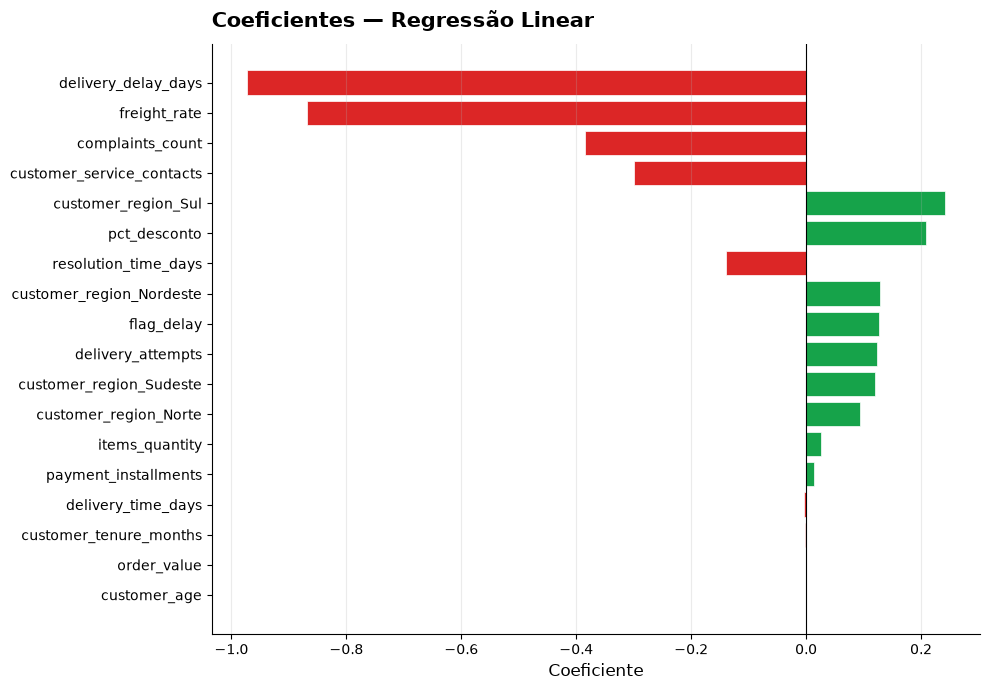

In [82]:
coef_lr = (
    pd.DataFrame({"Feature": X_train.columns, "Coeficiente": lr.coef_})
    .sort_values("Coeficiente", key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#DC2626" if c < 0 else "#16A34A" for c in coef_lr["Coeficiente"]]
ax.barh(coef_lr["Feature"], coef_lr["Coeficiente"], color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes — Regressão Linear", fontsize=15, fontweight="bold", loc="left", pad=12)
ax.set_xlabel("Coeficiente", fontsize=12)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Conclusões**

- A Regressão Linear serve como baseline interpretável. Os coeficientes confirmam os achados da EDA: `delivery_delay_days` e `complaints_count` têm os maiores coeficientes negativos, sendo os principais drivers de queda no NPS.
- Variáveis sem associação identificada na EDA (ex.: `freight_rate`, `payment_installments`) apresentam coeficientes próximos de zero, como esperado.

#### 6.2. Ridge

In [83]:
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=par_kfold)
ridge, y_pred_ridge, res_ridge = avaliar_modelo("Ridge", ridge, X_train, X_test, y_train, y_test)
resultados.append(res_ridge)

print(f"Melhor alpha Ridge (via CV): {ridge.alpha_:.4f}")
print("\nRidge — Resultados:")
for k, v in res_ridge.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Melhor alpha Ridge (via CV): 10.0000

Ridge — Resultados:
  RMSE (teste): 1.6965
  MAE (teste): 1.3303
  R² (teste): 0.5406
  RMSE CV (treino): 1.6672


**Conclusões**

- Ridge aplica regularização L2, penalizando coeficientes grandes sem zerá-los. É especialmente útil para lidar com a multicolinearidade entre `complaints_count` e `customer_service_contacts` (correlação de 0,75 identificada na EDA).
- O alpha ótimo é selecionado via cross-validation no conjunto de treino.

#### 6.3. Lasso

In [84]:
lasso = LassoCV(
    alphas=[0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    cv=par_kfold,
    max_iter=10000,
    random_state=par_random_state,
)
lasso, y_pred_lasso, res_lasso = avaliar_modelo("Lasso", lasso, X_train, X_test, y_train, y_test)
resultados.append(res_lasso)

print(f"Melhor alpha Lasso (via CV): {lasso.alpha_:.4f}")

coef_lasso = pd.Series(lasso.coef_, index=X_train.columns)
features_zeradas = coef_lasso[coef_lasso == 0].index.tolist()
print(f"\nFeatures eliminadas pelo Lasso ({len(features_zeradas)}): {features_zeradas}")

print("\nLasso — Resultados:")
for k, v in res_lasso.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Melhor alpha Lasso (via CV): 0.0010

Features eliminadas pelo Lasso (0): []

Lasso — Resultados:
  RMSE (teste): 1.6969
  MAE (teste): 1.331
  R² (teste): 0.5404
  RMSE CV (treino): 1.6691


**Conclusões**

- Lasso aplica regularização L1, que zera coeficientes de variáveis irrelevantes, funcionando como seleção automática de features.
- As variáveis eliminadas pelo Lasso corroboram os achados da EDA: aquelas sem associação direta com NPS tendem a ter coeficiente zerado.

#### 6.4. Random Forest Regressor

In [85]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=par_random_state,
    n_jobs=-1,
)
rf, y_pred_rf, res_rf = avaliar_modelo("Random Forest", rf, X_train, X_test, y_train, y_test)
resultados.append(res_rf)

print("Random Forest — Resultados:")
for k, v in res_rf.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Random Forest — Resultados:
  RMSE (teste): 1.7143
  MAE (teste): 1.3483
  R² (teste): 0.5309
  RMSE CV (treino): 1.7189


**Conclusões**

- Random Forest captura interações não-lineares entre variáveis sem necessitar de normalização de escala.
- A comparação de RMSE com os modelos lineares indicará se há ganho relevante ao capturar não-linearidades nos dados.

#### 6.5. Gradient Boosting

In [86]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=par_random_state,
)
gb, y_pred_gb, res_gb = avaliar_modelo("Gradient Boosting", gb, X_train, X_test, y_train, y_test)
resultados.append(res_gb)

print("Gradient Boosting — Resultados:")
for k, v in res_gb.items():
    if k != "Modelo":
        print(f"  {k}: {v}")

Gradient Boosting — Resultados:
  RMSE (teste): 1.7209
  MAE (teste): 1.3553
  R² (teste): 0.5273
  RMSE CV (treino): 1.7021


**Conclusões**

- Gradient Boosting constrói árvores sequencialmente, corrigindo os erros do modelo anterior. Tende a ser o modelo com melhor performance preditiva na maioria dos problemas tabulares.
- O `subsample=0.8` introduz aleatoriedade em cada árvore, reduzindo overfitting.

### 7. Comparação dos modelos

In [87]:
df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados

,RMSE (teste),MAE (teste),R² (teste),RMSE CV (treino)
Modelo,,,,
Regressão Linear,1.6974,1.3317,0.5401,1.6669
Ridge,1.6965,1.3303,0.5406,1.6672
Lasso,1.6969,1.3310,0.5404,1.6691
Random Forest,1.7143,1.3483,0.5309,1.7189
Gradient Boosting,1.7209,1.3553,0.5273,1.7021


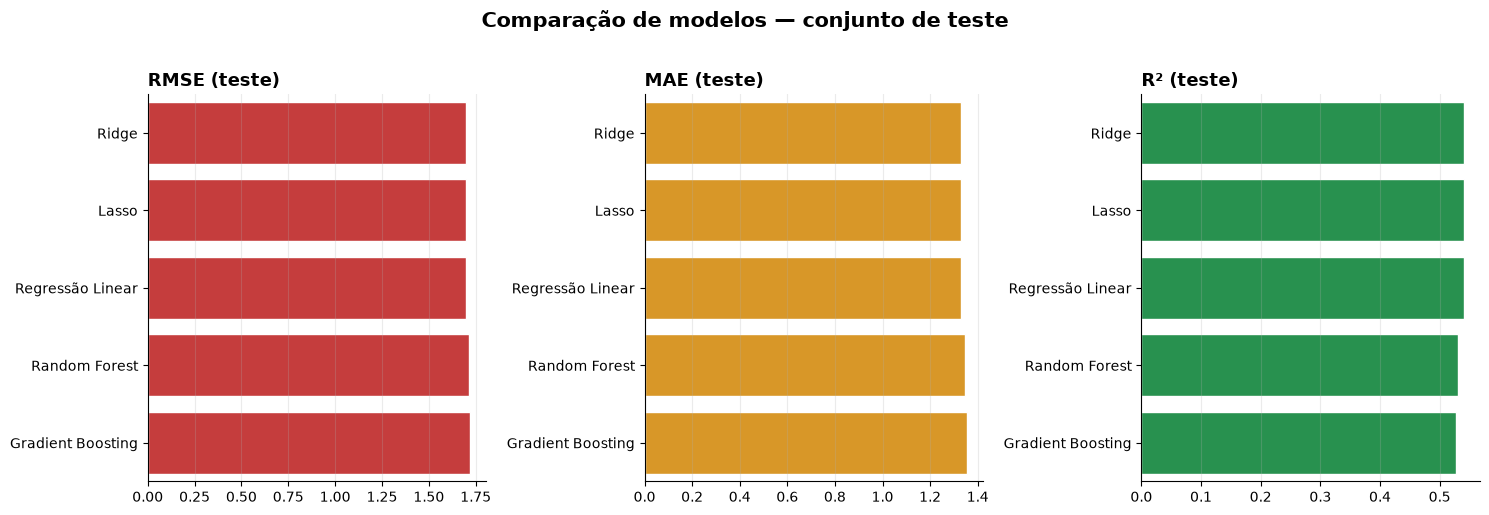

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metricas = ["RMSE (teste)", "MAE (teste)", "R² (teste)"]
cores = ["#DC2626", "#F59E0B", "#16A34A"]
ascendente = [True, True, False]  # menor RMSE/MAE é melhor; maior R² é melhor

for ax, metrica, cor, asc in zip(axes, metricas, cores, ascendente):
    df_plot = df_resultados[[metrica]].sort_values(metrica, ascending=asc).reset_index()
    sns.barplot(data=df_plot, x=metrica, y="Modelo", color=cor, ax=ax, edgecolor="white")
    ax.set_title(metrica, fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    sns.despine(ax=ax)

plt.suptitle("Comparação de modelos — conjunto de teste", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

**Conclusões**

- A tabela e os gráficos permitem comparar os modelos nas três métricas de regressão definidas na estratégia.
- Modelos não-lineares (Random Forest e Gradient Boosting) tendem a apresentar RMSE e MAE menores por capturarem interações entre variáveis que os modelos lineares assumem ser independentes.
- A diferença entre `RMSE CV (treino)` e `RMSE (teste)` indica o grau de generalização de cada modelo — valores próximos sugerem boa estabilidade.
- O melhor modelo por RMSE no teste será utilizado na análise da seção 8.

### 8. Análise do melhor modelo

In [89]:
nome_melhor = df_resultados["RMSE (teste)"].idxmin()
print(f"Melhor modelo por RMSE no teste: {nome_melhor}")

modelos_dict = {
    "Regressão Linear": (lr, y_pred_lr),
    "Ridge": (ridge, y_pred_ridge),
    "Lasso": (lasso, y_pred_lasso),
    "Random Forest": (rf, y_pred_rf),
    "Gradient Boosting": (gb, y_pred_gb),
}
melhor_modelo, y_pred_melhor = modelos_dict[nome_melhor]

Melhor modelo por RMSE no teste: Ridge


#### 8.1. Validação cruzada e Grid Search no Gradient Boosting

Antes de seguir para a interpretação do melhor modelo, foi feito um ajuste adicional no `GradientBoostingRegressor`. A primeira versão do Gradient Boosting usou hiperparâmetros definidos manualmente.

Agora, nessa etapa, testamos combinações alternativas com `GridSearchCV` e validação cruzada em 5 folds.

O objetivo é verificar se os modelos de árvore testado estavam sendo prejudicados por uma configuração inicial pouco adequada. A busca é feita **somente no conjunto de treino**, usando RMSE como métrica de otimização, para evitar vazamento de informação do conjunto de teste. Depois, o melhor estimador encontrado é avaliado no teste e comparado com os resultados anteriores.

Para evitar overfitting, a comparação não deve olhar apenas o RMSE no teste. É importante comparar três leituras: `RMSE (treino)`, `RMSE CV (treino)` e `RMSE (teste)`. Se o erro no treino for muito menor do que o erro em validação cruzada e teste, o modelo provavelmente memorizou padrões específicos do treino. Se CV e teste ficam próximos, há maior evidência de generalização.


In [90]:
cv_grid = KFold(
    n_splits=5,
    shuffle=True,
    random_state=par_random_state,
)

gb_param_grid = {
    "n_estimators": [150, 300],
    "learning_rate": [0.03, 0.05],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0],
    "min_samples_leaf": [1, 5],
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=par_random_state),
    param_grid=gb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_grid,
    n_jobs=-1,
    return_train_score=True,
)

gb_grid.fit(X_train, y_train)

nome_gb_otimizado = "Gradient Boosting com Hiperparâmetros Otimizados"
gb_otimizado = gb_grid.best_estimator_
y_pred_gb_otimizado_train = gb_otimizado.predict(X_train)
y_pred_gb_otimizado = gb_otimizado.predict(X_test)

rmse_train_gb_otimizado = np.sqrt(mean_squared_error(y_train, y_pred_gb_otimizado_train))
rmse_test_gb_otimizado = np.sqrt(mean_squared_error(y_test, y_pred_gb_otimizado))
rmse_cv_gb_otimizado = -gb_grid.best_score_
gap_teste_cv_gb_otimizado = rmse_test_gb_otimizado - rmse_cv_gb_otimizado

res_gb_otimizado = {
    "Modelo": nome_gb_otimizado,
    "RMSE (treino)": round(rmse_train_gb_otimizado, 4),
    "RMSE (teste)": round(rmse_test_gb_otimizado, 4),
    "MAE (teste)": round(mean_absolute_error(y_test, y_pred_gb_otimizado), 4),
    "R² (teste)": round(r2_score(y_test, y_pred_gb_otimizado), 4),
    "RMSE CV (treino)": round(rmse_cv_gb_otimizado, 4),
    "Gap teste-CV": round(gap_teste_cv_gb_otimizado, 4),
}

print("Melhores hiperparâmetros do Gradient Boosting:")
print(gb_grid.best_params_)

print(f"\n{nome_gb_otimizado} - Resultados:")
for k, v in res_gb_otimizado.items():
    if k != "Modelo":
        print(f"  {k}: {v}")


Melhores hiperparâmetros do Gradient Boosting:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 150, 'subsample': 1.0}

Gradient Boosting com Hiperparâmetros Otimizados - Resultados:
  RMSE (treino): 1.4959
  RMSE (teste): 1.6795
  MAE (teste): 1.3201
  R² (teste): 0.5498
  RMSE CV (treino): 1.6656
  Gap teste-CV: 0.0139


In [91]:
df_resultados_grid = pd.concat(
    [
        df_resultados,
        pd.DataFrame([res_gb_otimizado]).set_index("Modelo"),
    ]
)

df_comparacao_gb = df_resultados_grid.loc[
    ["Gradient Boosting", nome_gb_otimizado, nome_melhor]
].drop_duplicates()

df_comparacao_gb


,RMSE (teste),MAE (teste),R² (teste),RMSE CV (treino),RMSE (treino),Gap teste-CV
Modelo,,,,,,
Gradient Boosting,1.7209,1.3553,0.5273,1.7021,NaN,NaN
Gradient Boosting com Hiperparâmetros Otimizados,1.6795,1.3201,0.5498,1.6656,1.4959,0.0139
Ridge,1.6965,1.3303,0.5406,1.6672,NaN,NaN


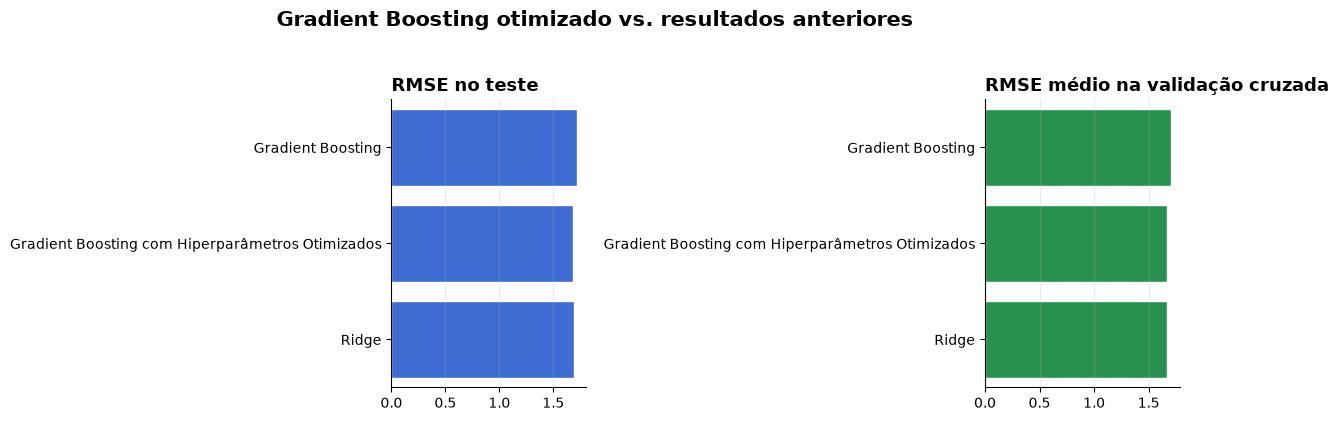

,Modelo,RMSE (treino),RMSE CV (treino),RMSE (teste),Gap teste-CV
0,Gradient Boosting com Hiperparâmetros Otimizados,1.4959,1.6656,1.6795,0.0139


O melhor modelo mudou de Ridge para Gradient Boosting com Hiperparâmetros Otimizados.


In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=df_comparacao_gb.reset_index(),
    x="RMSE (teste)",
    y="Modelo",
    color="#2563EB",
    edgecolor="white",
    ax=axes[0],
)
axes[0].set_title("RMSE no teste", fontsize=13, fontweight="bold", loc="left")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.25)

sns.barplot(
    data=df_comparacao_gb.reset_index(),
    x="RMSE CV (treino)",
    y="Modelo",
    color="#16A34A",
    edgecolor="white",
    ax=axes[1],
)
axes[1].set_title("RMSE médio na validação cruzada", fontsize=13, fontweight="bold", loc="left")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].grid(axis="x", alpha=0.25)

for ax in axes:
    sns.despine(ax=ax)

plt.suptitle("Gradient Boosting otimizado vs. resultados anteriores", fontsize=15, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

display(
    pd.DataFrame([res_gb_otimizado])[[
        "Modelo",
        "RMSE (treino)",
        "RMSE CV (treino)",
        "RMSE (teste)",
        "Gap teste-CV",
    ]]
)

nome_melhor_pos_grid = df_resultados_grid["RMSE (teste)"].idxmin()

modelos_dict[nome_gb_otimizado] = (gb_otimizado, y_pred_gb_otimizado)

if nome_melhor_pos_grid != nome_melhor:
    print(f"O melhor modelo mudou de {nome_melhor} para {nome_melhor_pos_grid}.")
    nome_melhor = nome_melhor_pos_grid
    melhor_modelo, y_pred_melhor = modelos_dict[nome_melhor]
    df_resultados = df_resultados_grid.copy()
else:
    print(f"O melhor modelo permanece: {nome_melhor}.")


**Conclusões**

- A inclusão do Grid Search torna a comparação mais justa para o `GradientBoostingRegressor`, porque o modelo deixa de depender apenas de uma configuração manual inicial.
- Nesta análise, o `Gradient Boosting com Hiperparâmetros Otimizados` apresentou uma pequena melhora em relação ao melhor modelo anterior, sem ser observada nenhuma evidência de overfitting. No entanto, é válido destacarmos que os modelos lineares testados apresentaram performance muito similar.

- Para avaliar risco de overfitting, devem ser comparados `RMSE (treino)`, `RMSE CV (treino)` e `RMSE (teste)`. Um treino muito melhor do que CV/teste indicaria memorização do conjunto de treino; CV e teste próximos indicam maior estabilidade fora da amostra usada no ajuste.
- Como a busca de hiperparâmetros usa apenas o treino, o conjunto de teste continua funcionando como validação final de generalização.


#### 8.2. Feature Importance

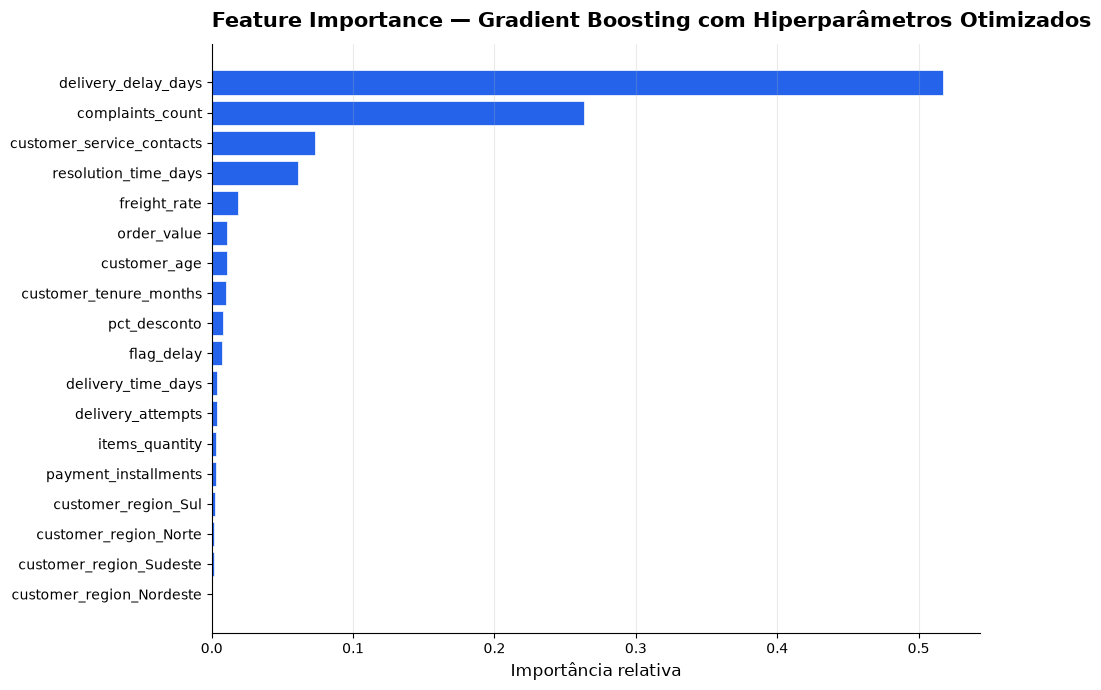


Top 5 features mais importantes:
                  Feature  Importância
      delivery_delay_days     0.517558
         complaints_count     0.262985
customer_service_contacts     0.073300
     resolution_time_days     0.061226
             freight_rate     0.018706


In [93]:
if hasattr(melhor_modelo, "feature_importances_"):
    importancias = melhor_modelo.feature_importances_
else:
    # Para modelos lineares: usa o valor absoluto dos coeficientes
    importancias = np.abs(melhor_modelo.coef_)

df_importancia = (
    pd.DataFrame({"Feature": X_train.columns, "Importância": importancias})
    .sort_values("Importância", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    df_importancia["Feature"],
    df_importancia["Importância"],
    color="#2563EB",
    edgecolor="white",
    linewidth=0.5,
)
ax.set_title(
    f"Feature Importance — {nome_melhor}",
    fontsize=15, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Importância relativa", fontsize=12)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("\nTop 5 features mais importantes:")
print(df_importancia.sort_values("Importância", ascending=False).head(5).to_string(index=False))

**Conclusões**

- A leitura de importância deve ser interpretada de acordo com o modelo selecionado após o Grid Search. Para modelos baseados em árvore, a importância vem de `feature_importances_`; para modelos lineares, usa-se a magnitude dos coeficientes.
- As variáveis mais relevantes ajudam a conectar o modelo aos achados da EDA, especialmente quando aparecem fatores logísticos, de atendimento ou de perfil já investigados nas hipóteses exploratórias.
- Essa análise não deve ser lida como causalidade, mas como um ranking de sinais usados pelo modelo para reduzir erro de previsão. Na prática, ela ajuda a priorizar quais variáveis merecem maior atenção operacional e analítica.


#### 8.3. Classificação derivada do NPS previsto

In [94]:
y_pred_classe = np.vectorize(classificar_nps)(y_pred_melhor)
y_true_classe = np.vectorize(classificar_nps)(y_test.values)

print("Distribuição das classes reais no teste:")
print(pd.Series(y_true_classe).value_counts())
print("\nDistribuição das classes previstas no teste:")
print(pd.Series(y_pred_classe).value_counts())

Distribuição das classes reais no teste:
Detrator    370
Neutro       90
Promotor     40
Name: count, dtype: int64

Distribuição das classes previstas no teste:
Detrator    402
Neutro       87
Promotor     11
Name: count, dtype: int64


#### 8.4. Métricas de classificação

In [95]:
ordem_classes = ["Detrator", "Neutro", "Promotor"]

print(f"Relatório de Classificação — {nome_melhor}")
print("(classificação derivada da previsão contínua de NPS)\n")
print(classification_report(y_true_classe, y_pred_classe, labels=ordem_classes))

Relatório de Classificação — Gradient Boosting com Hiperparâmetros Otimizados
(classificação derivada da previsão contínua de NPS)

              precision    recall  f1-score   support

    Detrator       0.87      0.94      0.90       370
      Neutro       0.51      0.49      0.50        90
    Promotor       0.55      0.15      0.24        40

    accuracy                           0.80       500
   macro avg       0.64      0.53      0.54       500
weighted avg       0.78      0.80      0.78       500



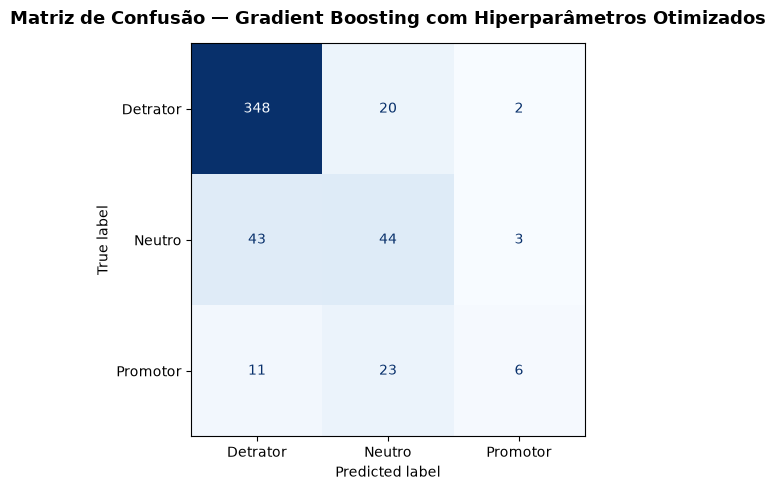

In [96]:
cm = confusion_matrix(y_true_classe, y_pred_classe, labels=ordem_classes)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordem_classes)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"Matriz de Confusão — {nome_melhor}",
    fontsize=13, fontweight="bold", pad=14,
)
plt.tight_layout()
plt.show()

**Conclusões**

- A métrica de negócio prioritária é o **recall na classe Detrator**: o custo de não identificar um detrator (falso negativo — previsto como Neutro ou Promotor sendo Detrator) é maior do que acionar preventivamente um cliente que seria Neutro.
- A classe Neutro tende a ser a mais difícil de classificar por estar no limiar entre as outras duas categorias.
- A matriz de confusão mostra os padrões de erro do modelo: confusões entre classes adjacentes (Detrator↔Neutro) são esperadas e menos custosas do que confusões entre extremos (Detrator↔Promotor).

### 9. Conclusões Gerais

**Estratégia adotada**

Optou-se por um modelo de regressão para prever o `nps_score` diretamente (escala 0–10), derivando a classificação Detrator/Neutro/Promotor a partir da nota prevista. Essa abordagem preserva a granularidade da informação e permite que um único modelo responda tanto à pergunta de regressão ("qual será a nota?") quanto à de classificação ("esse cliente será promotor ou detrator?").

**Principais achados**

- As variáveis logísticas e de atendimento (`delivery_delay_days`, `complaints_count`, `flag_delay`) seguem como sinais centrais para explicar a variação do NPS, em linha com os achados da EDA.
- Após a otimização de hiperparâmetros, o Gradient Boosting passou a ser o modelo com melhor desempenho, mostrando a relevância de realizar um bom tuning dos parâmetros durante a modelagem. No entanto, ressaltamos novamente o bom desempenho de modelos de regressão, que são mais simples e fáceis de explicar para áreas de negócio, embora os modelos de árvore também tenham boa interpretabilidade.
- Não foi observado sinal de overfitting no modelo com melhor performance, o que é evidenciado pela diferença não significativa das métricas entre o conjunto de teste e os folds da validação cruzada durante o treino.
- O Lasso confirmou a baixa relevância preditiva de algumas features que a EDA já havia indicado sem associação direta com NPS.

**Como usar na prática**

Com esse modelo, a empresa pode, ao encerrar a jornada de entrega e atendimento de um pedido (antes de aplicar a pesquisa de NPS), calcular o score previsto para cada cliente. Clientes com score previsto ≤ 6 seriam priorizados para ações proativas de recuperação — contato de atendimento, compensação ou resolução antecipada de problemas — antes de se tornarem detratores declarados.

**Limitações**

- Os resultados são observacionais; associação não implica causalidade.
- O modelo foi treinado em uma amostra estática; performance pode variar com novos dados ao longo do tempo.
- A classe Neutro é sub-representada e tende a ser mais difícil de prever com precisão.

**Próximos passos sugeridos em um projeto real**:
- Incluir uma etapa de observabilidade das métricas e retreino do modelo em caso de degradação da performance.
- Incluir novas variáveis de perfil dos clientes que estejam mais correlacionadas à variável alvo, se possível.
**Próximos passos sugeridos em um projeto real**:
- Incluir uma etapa de observabilidade das métricas e retreino do modelo em caso de degradação da performance.
- Incluir novas variáveis de perfil dos clientes que estejam mais correlacionadas à variável alvo, se possível.
- Estudar refinamentos no modelo utilizado, incluindo modelos mais robustos, novas features e métricas de avaliação complementares. Por exemplo, como o NPS é uma variável limitada entre 0 e 10, o uso exclusivo de RMSE pode favorecer previsões mais próximas da média e reduzir a capacidade do modelo de representar corretamente valores extremos, como promotores ou detratores muito insatisfeitos. 
